In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from datetime import datetime
from scipy.stats import chi2_contingency

# Analyse Descriptive

In [29]:
df = pd.read_excel('data/working_dataset.xlsx')

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df.head(3)

,DATE_OPERATION,INDLIB_GROUPE,PORTEF,MONTANT,DUREE,PERIODE,TAUX_INT,NB_ECH,SEX,A_GARANTIE,AGENCE_LIEU,IMPAYE,NBIMP,MNTREMB,AGE,ETATCIVIL,WILAYA_NAISSANCE,TYPE_CLIENT,DEFAUT
0,2013-07-18,Services,DDC,2500000.0,48,T,5.0,16,Male,Non,Nouakchott,0.0,0,180785.84,55,Married,Adrar,Public,0
1,2013-07-21,Commerce,DDC,2500000.0,48,T,5.0,16,Male,Non,Nouakchott,0.0,0,180785.84,67,Single,Inconnu,Public,0
2,2013-07-21,Services,DDC,2500000.0,48,T,5.0,16,Male,Non,Nouakchott,0.0,0,180785.84,58,Married,Adrar,Public,0


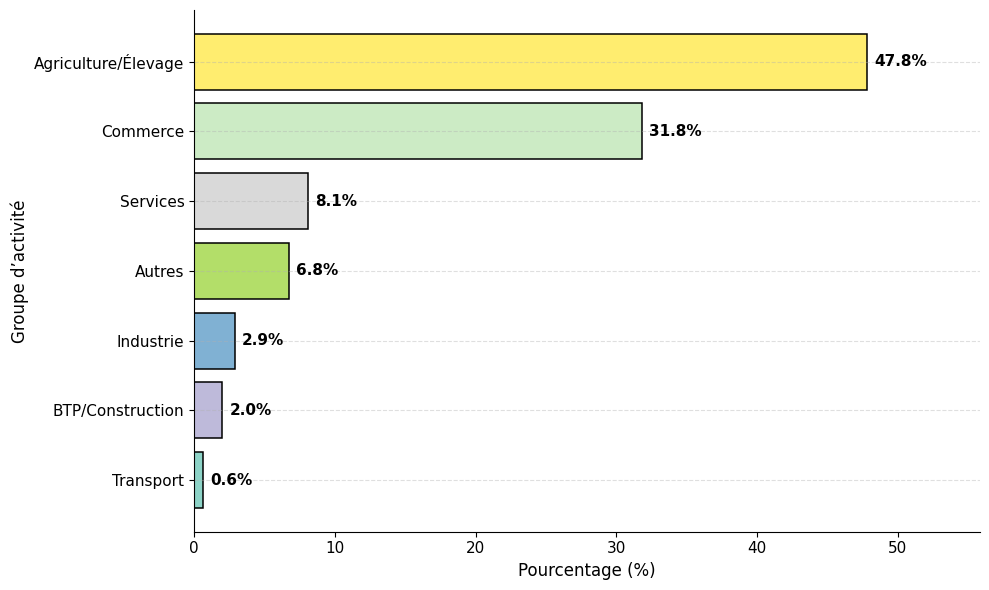

In [54]:
# Calcul des pourcentages
data = (
    df['INDLIB_GROUPE']
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=True)   # ascending=True pour un beau graphique horizontal
)

# Palette de couleurs
colors = plt.cm.Set3(np.linspace(0, 1, len(data)))

# Création du graphique
plt.figure(figsize=(10, 6))

bars = plt.barh(
    data.index,
    data.values,
    color=colors,
    edgecolor='black',
    linewidth=1.1
)

# Ajouter les pourcentages au bout des barres
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}%',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# Personnalisation
# plt.title("Distribution de l'activité économique", fontsize=16, fontweight='bold')
plt.xlabel('Pourcentage (%)', fontsize=12)
plt.ylabel('Groupe d’activité', fontsize=12)

plt.xlim(0, data.max() + 8)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.4)

# Supprimer les bordures inutiles
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Ce graphique présente la répartition des bénéficiaires selon le groupe d’activité économique. On remarque que l’activité est fortement concentrée dans deux secteurs principaux : l’Agriculture/Élevage, qui représente 47,8 % des observations, et le Commerce, avec 31,8 %. Ces deux groupes regroupent donc la grande majorité des dossiers étudiés. Les autres secteurs sont beaucoup moins représentés, notamment les Services avec 8,1 %, les Autres activités avec 6,8 %, puis l’Industrie, le BTP/Construction et le Transport, qui occupent des parts très faibles. Cette répartition montre que le portefeuille étudié est principalement orienté vers les activités agricoles, pastorales et commerciales, ce qui reflète probablement l’importance de ces secteurs dans les financements accordés par la CDD.

### PORTEF

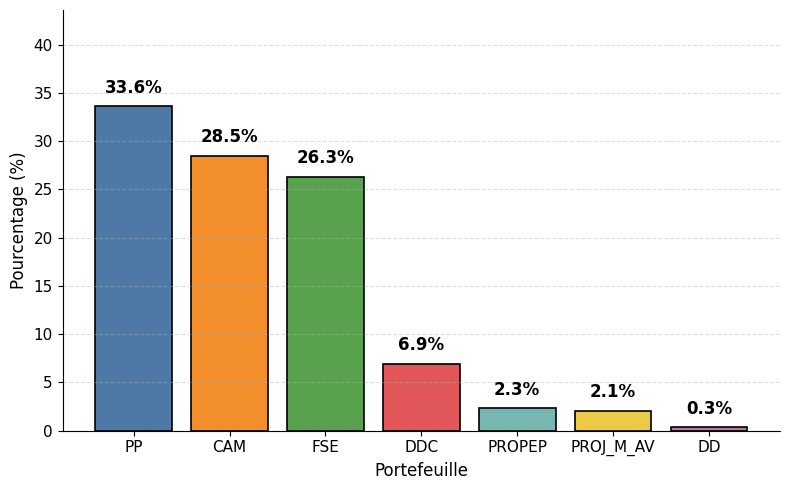

In [55]:
# Calcul des pourcentages
data = df['PORTEF'].value_counts(normalize=True).mul(100).sort_values(ascending=False)

# Une couleur différente pour chaque barre
colors = [
    '#4E79A7',  # bleu
    '#F28E2B',  # orange
    '#59A14F',  # vert
    '#E15759',  # rouge
    '#76B7B2',  # turquoise
    '#EDC948',  # jaune
    '#B07AA1'   # violet
]

# Création du graphique
plt.figure(figsize=(8, 5))

bars = plt.bar(
    data.index,
    data.values,
    color=colors[:len(data)],
    edgecolor='black',
    linewidth=1.2
)

# Ajouter les pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

# Personnalisation
# plt.title('Distribution du portefeuille', fontsize=16, fontweight='bold')
plt.xlabel('Portefeuille', fontsize=12)
plt.ylabel('Pourcentage (%)', fontsize=12)

plt.ylim(0, data.max() + 10)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.4)

# Supprimer les bordures inutiles
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Ce graphique montre la répartition des dossiers selon le type de portefeuille. On observe que trois portefeuilles dominent clairement l’ensemble des observations : PP représente 33,6 %, suivi de CAM avec 28,5 % et FSE avec 26,3 %. À eux seuls, ces trois portefeuilles regroupent la grande majorité des dossiers étudiés. Les autres catégories restent beaucoup moins présentes, notamment DDC avec 6,9 %, PROPEP avec 2,3 %, PROJ_M_AV avec 2,1 % et DD avec seulement 0,3 %. Cette structure montre que l’activité de financement est fortement concentrée autour de quelques portefeuilles principaux, tandis que les autres occupent une place plus marginale dans la base de données.

### Montant

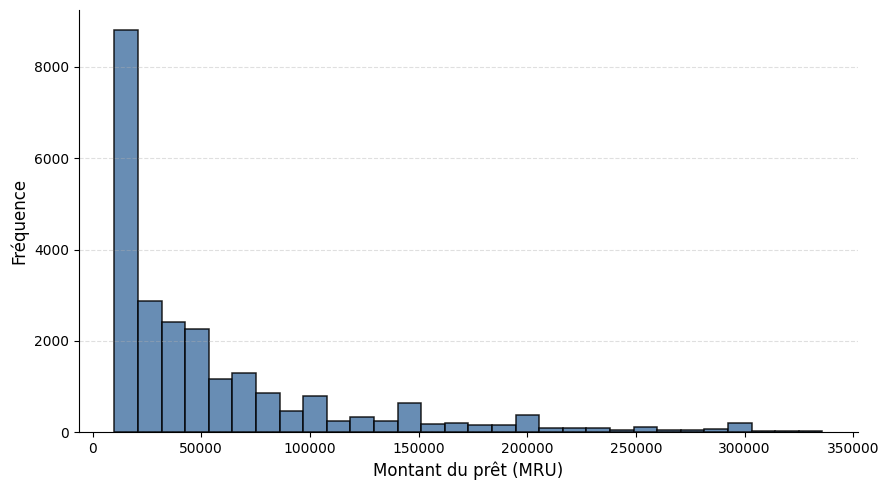

In [57]:
# Limiter l'affichage au 95e percentile
limite = df['MONTANT'].quantile(0.95)

data_montant = df[df['MONTANT'] <= limite]['MONTANT']

plt.figure(figsize=(9, 5))

plt.hist(
    data_montant,
    bins=30,
    color='#4E79A7',
    edgecolor='black',
    linewidth=1.1,
    alpha=0.85
)

# plt.title('Distribution du montant des prêts (hors valeurs extrêmes)', fontsize=15, fontweight='bold')
plt.xlabel('Montant du prêt (MRU)', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Ce graphique présente la distribution des montants de prêts, après exclusion des valeurs extrêmes. On observe que la majorité des prêts accordés sont de **faible montant**, avec une forte concentration dans les premières classes, surtout autour des montants inférieurs à **50 000 MRU**. Ensuite, la fréquence diminue progressivement lorsque le montant du prêt augmente. Cela montre que les prêts de montants élevés sont beaucoup plus rares dans la base. La distribution est donc asymétrique vers la droite, ce qui signifie que quelques prêts plus importants tirent la distribution vers les montants élevés, même après le retrait des valeurs extrêmes. Dans l’ensemble, le portefeuille étudié semble principalement composé de petits crédits.


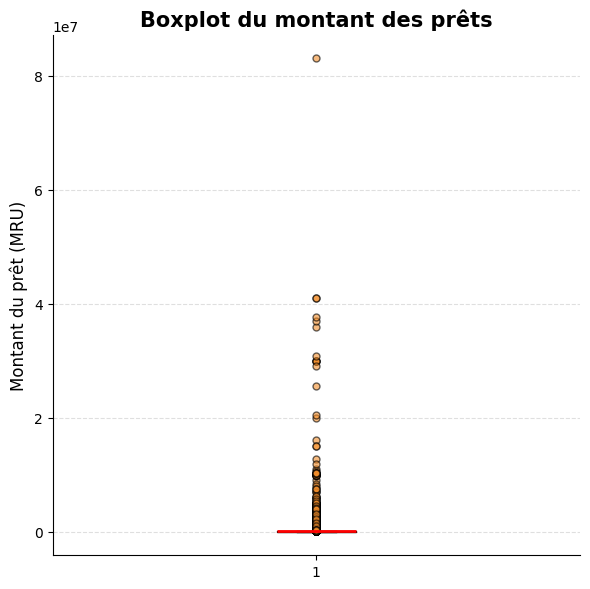

In [35]:
plt.figure(figsize=(6, 6))

plt.boxplot(
    df['MONTANT'].dropna(),
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='#4E79A7', color='black'),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(
        marker='o',
        markerfacecolor='#F28E2B',
        markeredgecolor='black',
        markersize=5,
        alpha=0.6
    )
)

plt.title('Boxplot du montant des prêts', fontsize=15, fontweight='bold')
plt.ylabel('Montant du prêt (MRU)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Duree

In [36]:
df['DUREE'].describe()

count    25680.000000
mean        26.687695
std         14.161317
min          1.000000
25%          6.000000
50%         36.000000
75%         36.000000
max         96.000000
Name: DUREE, dtype: float64

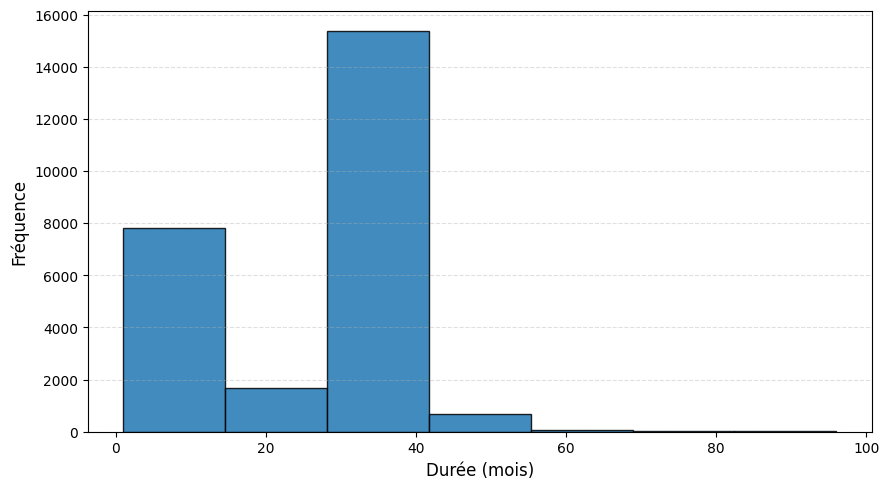

In [58]:
plt.figure(figsize=(9, 5))

plt.hist(
    df['DUREE'].dropna(),
    bins=7,
    edgecolor='black',
    alpha=0.85
)

# plt.title("Distribution de la durée des prêts", fontsize=14, fontweight='bold')
plt.xlabel("Durée (mois)", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Ce graphique montre la répartition des prêts selon leur durée en mois. On remarque que la majorité des prêts se concentre autour des durées comprises entre **30 et 40 mois**, ce qui indique que les financements accordés sont principalement de moyen terme. Une autre partie importante des prêts se situe dans les durées courtes, notamment en dessous de **15 mois**. En revanche, les prêts de longue durée, au-delà de **50 mois**, sont très peu nombreux. Cette distribution montre donc que la CDD accorde surtout des prêts sur des durées relativement limitées, avec une forte concentration autour de quelques durées principales.


### PERIODE

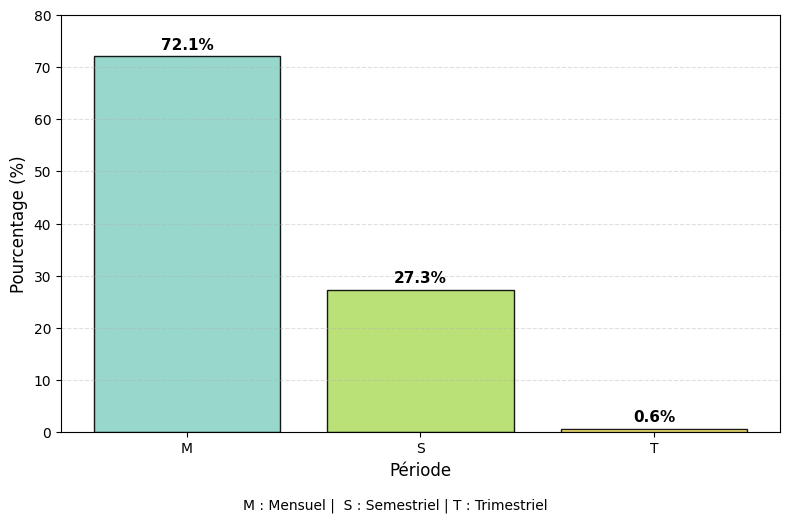

In [59]:
data = df['PERIODE'].value_counts(normalize=True).mul(100)

plt.figure(figsize=(8, 5))

colors = plt.cm.Set3(np.linspace(0, 1, len(data)))

bars = plt.bar(
    data.index,
    data.values,
    color=colors,
    edgecolor='black',
    alpha=0.9
)

# Add percentages on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# plt.title("Distribution de la période de remboursement", fontsize=14, fontweight='bold')
plt.xlabel("Période", fontsize=12)
plt.ylabel("Pourcentage (%)", fontsize=12)

plt.xticks(rotation=0)
plt.ylim(0, data.max() + 8)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.figtext(
    0.5, -0.03,
    "M : Mensuel |  S : Semestriel | T : Trimestriel",
    ha='center',
    fontsize=10
)

plt.tight_layout()
plt.show()

Ce graphique présente la répartition des prêts selon la période de remboursement. On constate que le remboursement **mensuel** domine largement, avec **72,1 %** des dossiers. Il est suivi par le remboursement **semestriel**, qui représente **27,3 %**. En revanche, le remboursement **trimestriel** reste presque absent, avec seulement **0,6 %** des observations. Cette répartition montre que la plupart des prêts sont remboursés de manière régulière chaque mois, ce qui peut faciliter le suivi des échéances et la gestion du risque. Le remboursement semestriel reste aussi important, mais il concerne une part plus limitée des bénéficiaires.


### TAUX_INT

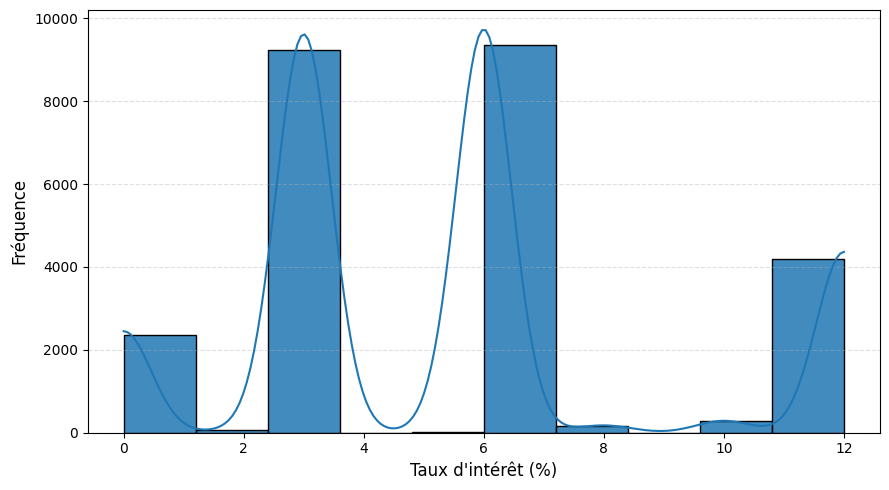

In [60]:
data = df['TAUX_INT'].dropna()

plt.figure(figsize=(9, 5))

sns.histplot(
    data,
    bins=10,
    kde=True,
    edgecolor='black',
    alpha=0.85
)

# plt.title("Distribution du taux d'intérêt", fontsize=14, fontweight='bold')
plt.xlabel("Taux d'intérêt (%)", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Ce graphique présente la répartition des prêts selon le taux d’intérêt appliqué. On remarque que les taux ne sont pas répartis de manière continue, mais se concentrent autour de quelques valeurs principales. Les taux les plus fréquents se situent surtout autour de 3 % et 6 %, avec aussi une présence importante autour de 12 %. Les autres taux apparaissent beaucoup plus rarement. Cette situation montre que la CDD applique probablement des taux d’intérêt standardisés selon le type de prêt, le portefeuille ou les conditions de financement. Ainsi, le taux d’intérêt semble moins varier librement d’un dossier à l’autre, mais plutôt suivre quelques barèmes précis.

### NBRE ECH

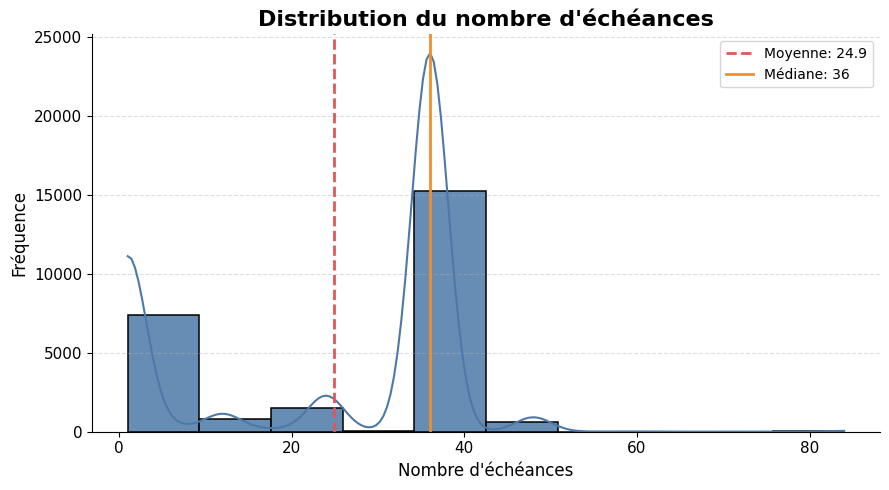

In [40]:
plt.figure(figsize=(9, 5))

ax = sns.histplot(
    df['NB_ECH'],
    bins=10,
    kde=True,
    color='#4E79A7',
    edgecolor='black',
    linewidth=1.1,
    alpha=0.85
)

# Moyenne et médiane
mean_nb_ech = df['NB_ECH'].mean()
median_nb_ech = df['NB_ECH'].median()

plt.axvline(
    mean_nb_ech,
    color='#E15759',
    linestyle='--',
    linewidth=2,
    label=f'Moyenne: {mean_nb_ech:.1f}'
)

plt.axvline(
    median_nb_ech,
    color='#F28E2B',
    linestyle='-',
    linewidth=2,
    label=f'Médiane: {median_nb_ech:.0f}'
)

# Personnalisation
plt.title("Distribution du nombre d'échéances", fontsize=16, fontweight='bold')
plt.xlabel("Nombre d'échéances", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.legend(frameon=True)

# IMPORTANT: supprimer les lignes verticales
ax.grid(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Supprimer les bordures inutiles
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### SEXE

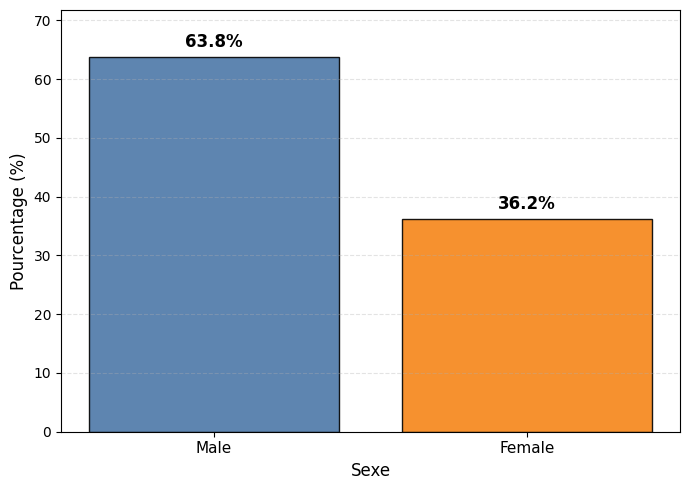

In [61]:
data = df['SEX'].value_counts(normalize=True).mul(100)

# Cool standard colors
colors = ['#4C78A8', '#F58518']  # blue + orange

plt.figure(figsize=(7, 5))

bars = plt.bar(
    data.index,
    data.values,
    color=colors[:len(data)],
    edgecolor='black',
    linewidth=1,
    alpha=0.9
)

# Add percentages on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

# plt.title("Répartition selon le sexe", fontsize=15, fontweight='bold')
plt.xlabel("Sexe", fontsize=12)
plt.ylabel("Pourcentage (%)", fontsize=12)

plt.ylim(0, data.max() + 8)
plt.xticks(rotation=0, fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

Ce graphique présente la distribution des bénéficiaires selon le sexe. On observe que les hommes sont majoritaires dans la base, avec **63,8 %** des dossiers, contre **36,2 %** pour les femmes. Cette différence montre que les financements étudiés concernent davantage les hommes que les femmes. Toutefois, la part des femmes reste relativement importante, ce qui indique qu’elles sont aussi présentes dans le portefeuille de prêts. Cette variable pourra être utile dans la suite de l’analyse pour vérifier si le niveau de défaut varie selon le sexe du bénéficiaire.


### AGENCE_LIEU

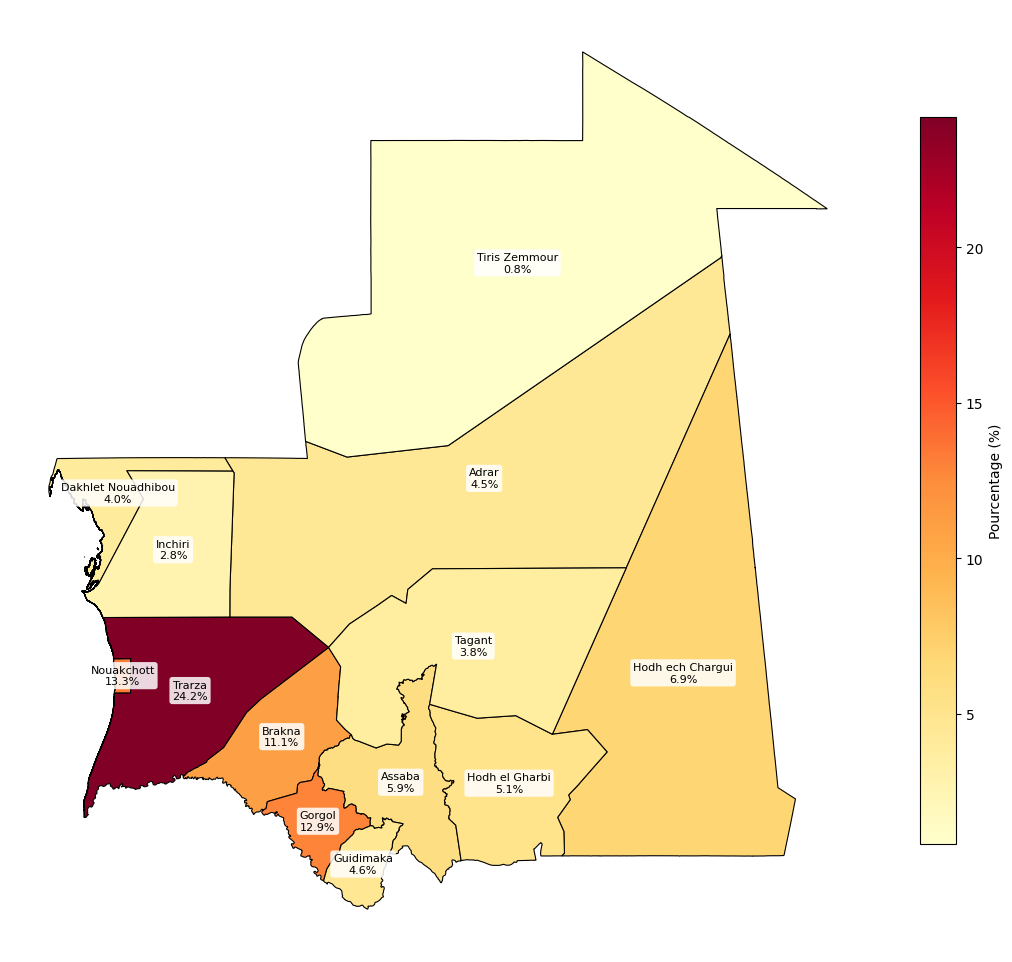

In [56]:
import geopandas as gpd

# =========================
# 1) Distribution en %
# =========================
data = (
    df['AGENCE_LIEU']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .reset_index()
)

data.columns = ['wilaya', 'pourcentage']


# =========================
# 2) Charger la carte de la Mauritanie
# =========================
gdf = gpd.read_file("shapefiles/gadm41_MRT_1.shp")

# Garder seulement le nom de la wilaya et la géométrie
gdf = gdf[['NAME_1', 'geometry']].rename(columns={'NAME_1': 'wilaya'})


# =========================
# 3) Harmoniser les noms des wilayas
# =========================

# Adapter les noms dans les données
data['wilaya'] = data['wilaya'].replace({
    'Dakhlet Nouadhibou': 'Dakhlet Nouadhibou',
    'Hodh Chargui': 'Hodh ech Chargui',
    'Hodh Gharbi': 'Hodh el Gharbi',
    'Tiris Zemmour': 'Tiris Zemmour',
    'Guidimagha': 'Guidimaka'
})

# Adapter les noms dans le shapefile
gdf['wilaya'] = gdf['wilaya'].replace({
    'Nouakchott Nord': 'Nouakchott',
    'Nouakchott Ouest': 'Nouakchott',
    'Nouakchott Sud': 'Nouakchott'
})

# Fusionner les parties de Nouakchott si elles existent
gdf = gdf.dissolve(by='wilaya', as_index=False)


# =========================
# 4) Fusionner les données avec la carte
# =========================
carte = gdf.merge(data, on='wilaya', how='left')

# Remplacer les wilayas sans données par 0
carte['pourcentage'] = carte['pourcentage'].fillna(0)


# =========================
# 5) Calculer les centroïdes pour placer les labels
# =========================
carte_proj = carte.to_crs(epsg=32628)
centroids = carte_proj.centroid.to_crs(carte.crs)


# =========================
# 6) Tracer la carte améliorée
# =========================
fig, ax = plt.subplots(figsize=(11, 10))

carte.plot(
    column='pourcentage',
    cmap='YlOrRd',
    linewidth=0.8,
    edgecolor='black',
    legend=True,
    legend_kwds={
        'label': "Pourcentage (%)",
        'shrink': 0.75
    },
    ax=ax
)


# =========================
# 7) Ajouter les labels
# =========================
for x, y, nom, pct in zip(
    centroids.x,
    centroids.y,
    carte['wilaya'],
    carte['pourcentage']
):
    if pct > 0:
        ax.text(
            x,
            y,
            f"{nom}\n{pct:.1f}%",
            ha='center',
            va='center',
            fontsize=8,
            bbox=dict(
                facecolor='white',
                alpha=0.85,
                edgecolor='none',
                boxstyle='round,pad=0.25'
            )
        )


# =========================
# 8) Titre et mise en forme
# =========================
# ax.set_title(
#     "Répartition des crédits selon le lieu de l’agence",
#     fontsize=15,
#     fontweight='bold',
#     pad=15
# )

ax.axis('off')

plt.tight_layout()
plt.show()

Cette carte présente la distribution des crédits selon la wilaya où se trouve l’agence. On observe que la part la plus importante des crédits est enregistrée au Trarza, avec 24,2 %. Cette wilaya se distingue clairement des autres et représente à elle seule près du quart des dossiers étudiés. Elle est suivie par Nouakchott avec 13,3 %, Gorgol avec 12,9 % et Brakna avec 11,1 %. Ces résultats montrent que l’activité de crédit est plus concentrée dans certaines zones, surtout dans le sud et le sud-ouest du pays. À l’inverse, quelques wilayas présentent des parts plus faibles, comme Tiris Zemmour avec 0,8 %, Inchiri avec 2,8 % et Tagant avec 3,8 %. Globalement, la carte montre que les crédits ne sont pas répartis de manière égale entre les agences, ce qui peut s’expliquer par la présence plus forte de certaines activités économiques, la demande locale de financement ou le volume d’activité de chaque agence.

### VALEURGARANT

In [43]:
data = df['VALEURGARANT'].dropna()

plt.figure(figsize=(9, 5))

sns.histplot(
    data,
    bins=10,
    kde=True,
    edgecolor='black',
    alpha=0.85
)

plt.title("Distribution de la valeur de la garantie", fontsize=14, fontweight='bold')
plt.xlabel("Valeur de la garantie", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

KeyError: 'VALEURGARANT'

### IMPAYE & NBIMP

In [44]:
(df['IMPAYE'] == 0).sum() / (df['IMPAYE'].count())

np.float64(0.48407320872274145)

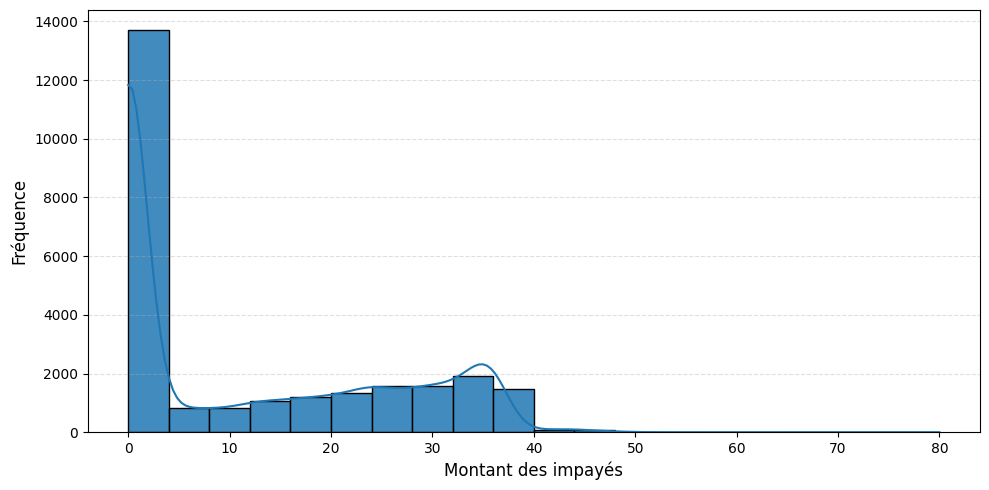

In [65]:
data = df['NBIMP'].dropna()

plt.figure(figsize=(10, 5))

sns.histplot(
    data,
    bins=20,
    kde=True,
    edgecolor='black',
    alpha=0.85
)

# plt.title("Distribution du montant des impayés", fontsize=15, fontweight='bold')
plt.xlabel("Montant des impayés", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)

# Format x-axis as money values
plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", " "))
)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Ce graphique montre la répartition des montants des impayés dans la base étudiée. On observe une très forte concentration des dossiers autour des faibles montants, notamment près de 0, ce qui signifie qu’une grande partie des prêts présente peu ou pas d’impayés. Ensuite, la fréquence diminue, même si l’on remarque une présence non négligeable d’impayés situés entre environ 20 et 40. Les montants les plus élevés restent rares. Cette distribution est donc très asymétrique, avec une majorité de dossiers à faible impayé et une minorité de dossiers présentant des niveaux d’impayés plus importants. Cela confirme l’intérêt d’utiliser cette variable dans la construction ou l’analyse du risque de défaut.

In [46]:
(df['NBIMP'] == 0).sum() / df.shape[0]

np.float64(0.48407320872274145)

### MNTREMB

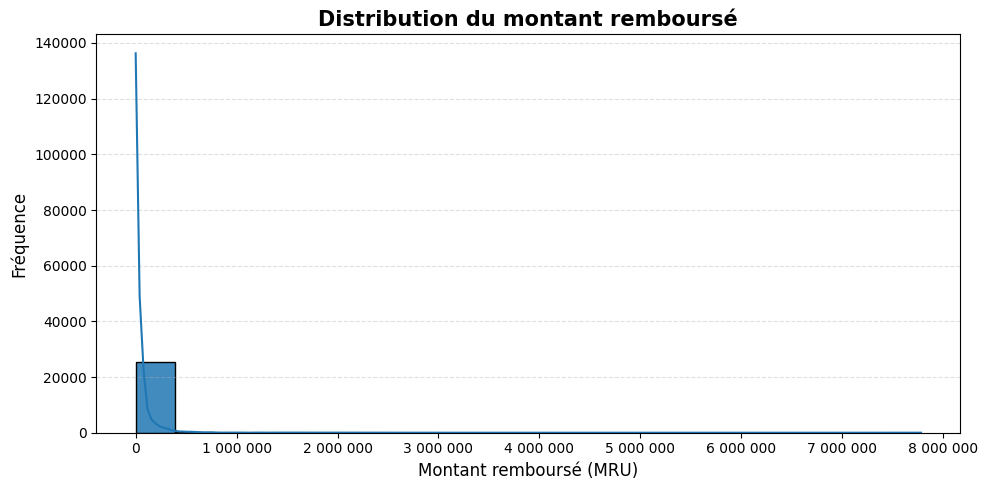

In [47]:
data = df['MNTREMB'].dropna()

plt.figure(figsize=(10, 5))

sns.histplot(
    data,
    bins=20,
    kde=True,
    edgecolor='black',
    alpha=0.85
)

plt.title("Distribution du montant remboursé", fontsize=15, fontweight='bold')
plt.xlabel("Montant remboursé (MRU)", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)

# Format x-axis values with spaces
plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", " "))
)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### AGE

In [48]:
# Remove GROUP_AGE if it already exists
df = df.drop(columns=['GROUP_AGE'], errors='ignore')

# Create age groups
group_age = pd.cut(
    df['AGE'],
    bins=[0, 34, 44, 54, 64, 120],
    labels=['Moins de 35', '35-44', '45-54', '55-64', '65 et plus'],
    right=True
)

# Insert GROUP_AGE directly after AGE
pos = df.columns.get_loc('AGE') + 1
df.insert(pos, 'GROUP_AGE', group_age)

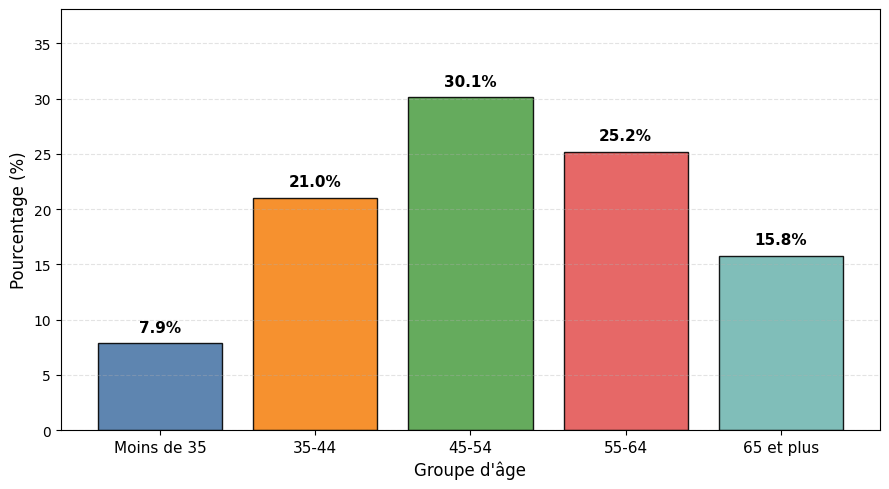

In [62]:
# Calculate percentages and keep the logical order of categories
ordre = ['Moins de 35', '35-44', '45-54', '55-64', '65 et plus']
data = (
    df['GROUP_AGE']
    .value_counts(normalize=True)
    .mul(100)
    .reindex(ordre)
)

# Clean and distinct colors
colors = ['#4C78A8', '#F58518', '#54A24B', '#E45756', '#72B7B2']

plt.figure(figsize=(9, 5))

bars = plt.bar(
    data.index,
    data.values,
    color=colors,
    edgecolor='black',
    linewidth=1,
    alpha=0.9
)

# Add percentages on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# plt.title("Répartition par groupe d'âge", fontsize=15, fontweight='bold')
plt.xlabel("Groupe d'âge", fontsize=12)
plt.ylabel("Pourcentage (%)", fontsize=12)

plt.xticks(rotation=0, fontsize=11)
plt.ylim(0, data.max() + 8)

plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

Ce graphique présente la distribution des bénéficiaires selon les groupes d’âge. On observe que la tranche 45-54 ans est la plus représentée, avec 30,1 % des dossiers. Elle est suivie par les groupes 55-64 ans avec 25,2 % et 35-44 ans avec 21,0 %. Les personnes âgées de 65 ans et plus représentent aussi une part non négligeable, avec 15,8 %, tandis que les bénéficiaires de moins de 35 ans sont les moins présents, avec seulement 7,9 %. Cette répartition montre que les prêts concernent principalement des personnes d’âge moyen ou avancé, ce qui peut refléter une plus grande présence de ces groupes dans les activités économiques financées.

### ETAT CIVIL

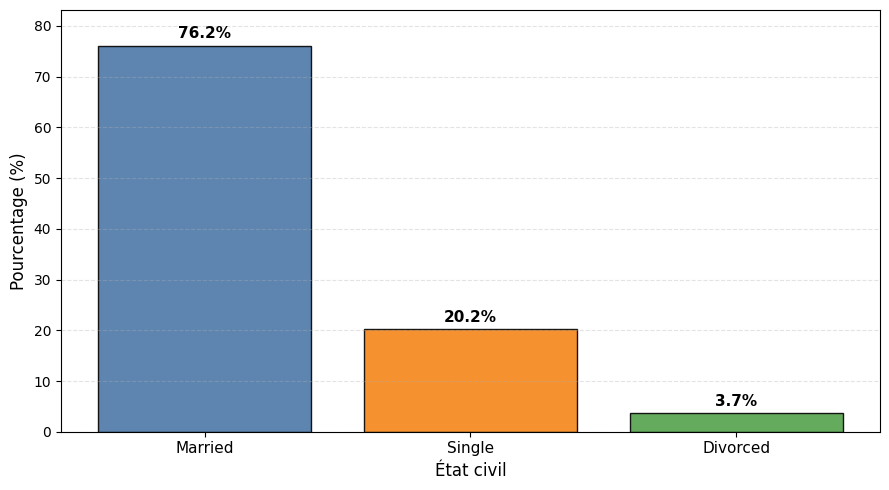

In [63]:
data = df['ETATCIVIL'].value_counts(normalize=True).mul(100)

# Cool standard colors
colors = ['#4C78A8', '#F58518', '#54A24B', '#E45756', '#72B7B2', '#B279A2']

plt.figure(figsize=(9, 5))

bars = plt.bar(
    data.index,
    data.values,
    color=colors[:len(data)],
    edgecolor='black',
    linewidth=1,
    alpha=0.9
)

# Percentages on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# plt.title("Répartition selon l'état civil", fontsize=15, fontweight='bold')
plt.xlabel("État civil", fontsize=12)
plt.ylabel("Pourcentage (%)", fontsize=12)

plt.xticks(rotation=0, fontsize=11)
plt.ylim(0, data.max() + 7)

plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

Ce graphique montre la distribution des bénéficiaires selon leur état civil. On constate que les personnes mariées sont largement majoritaires, avec 76,2 % des dossiers. Les personnes célibataires représentent 20,2 %, tandis que les personnes divorcées restent peu nombreuses, avec seulement 3,7 %. Cette répartition indique que le portefeuille étudié concerne surtout des bénéficiaires mariés. L’état civil pourra ensuite être examiné dans l’analyse bivariée afin de voir s’il existe une différence de comportement de remboursement ou de défaut entre les groupes.

### WILAYA_NAISSANCE

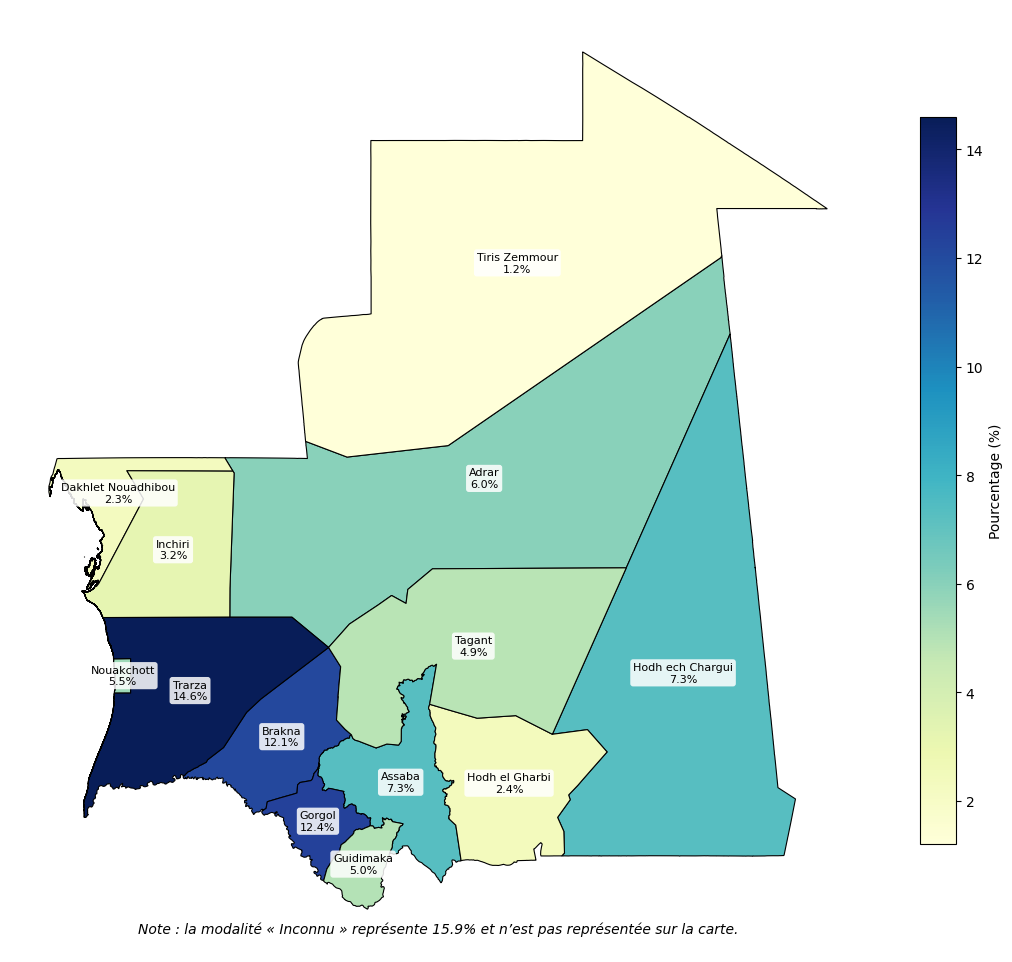

In [64]:
import geopandas as gpd

# =========================
# 1) Calculer la distribution en %
# =========================
data = (
    df['WILAYA_NAISSANCE']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .reset_index()
)

data.columns = ['wilaya', 'pourcentage']


# =========================
# 2) Garder le pourcentage des inconnus
# =========================
pct_inconnu = data.loc[data['wilaya'] == 'Inconnu', 'pourcentage']

if len(pct_inconnu) > 0:
    pct_inconnu = pct_inconnu.iloc[0]
else:
    pct_inconnu = 0


# =========================
# 3) Supprimer "Inconnu" de la carte
# =========================
data = data[data['wilaya'] != 'Inconnu'].copy()


# =========================
# 4) Charger la carte de la Mauritanie
# =========================
gdf = gpd.read_file("shapefiles/gadm41_MRT_1.shp")

gdf = gdf[['NAME_1', 'geometry']].rename(columns={'NAME_1': 'wilaya'})


# =========================
# 5) Harmoniser les noms des wilayas
# =========================

# Noms dans les données
data['wilaya'] = data['wilaya'].replace({
    'Nouadhibou': 'Dakhlet Nouadhibou',
    'Hodh Ech Chargui': 'Hodh ech Chargui',
    'Hodh el Gharbi': 'Hodh el Gharbi',
    'Tiris Zemmour': 'Tiris Zemmour',
    'Guidimakha': 'Guidimaka'
})

# Noms dans le shapefile
gdf['wilaya'] = gdf['wilaya'].replace({
    'Nouakchott Nord': 'Nouakchott',
    'Nouakchott Ouest': 'Nouakchott',
    'Nouakchott Sud': 'Nouakchott'
})

# Fusionner les parties de Nouakchott
gdf = gdf.dissolve(by='wilaya', as_index=False)


# =========================
# 6) Fusionner données + carte
# =========================
carte = gdf.merge(data, on='wilaya', how='left')

# Les wilayas sans observation deviennent 0
carte['pourcentage'] = carte['pourcentage'].fillna(0)


# =========================
# 7) Calculer les centroïdes pour les labels
# =========================
carte_proj = carte.to_crs(epsg=32628)
centroids = carte_proj.centroid.to_crs(carte.crs)


# =========================
# 8) Tracer la carte
# =========================
fig, ax = plt.subplots(figsize=(11, 10))

carte.plot(
    column='pourcentage',
    cmap='YlGnBu',
    linewidth=0.8,
    edgecolor='black',
    legend=True,
    legend_kwds={
        'label': "Pourcentage (%)",
        'shrink': 0.75
    },
    ax=ax
)


# =========================
# 9) Ajouter les labels
# =========================
for x, y, nom, pct in zip(
    centroids.x,
    centroids.y,
    carte['wilaya'],
    carte['pourcentage']
):
    if pct > 0:
        ax.text(
            x,
            y,
            f"{nom}\n{pct:.1f}%",
            ha='center',
            va='center',
            fontsize=8,
            bbox=dict(
                facecolor='white',
                alpha=0.85,
                edgecolor='none',
                boxstyle='round,pad=0.25'
            )
        )


# =========================
# 10) Titre et note sur Inconnu
# =========================
# ax.set_title(
#     "Répartition des clients selon la wilaya de naissance",
#     fontsize=15,
#     fontweight='bold',
#     pad=20
# )

ax.text(
    0.5,
    0.02,
    f"Note : la modalité « Inconnu » représente {pct_inconnu:.1f}% et n’est pas représentée sur la carte.",
    transform=ax.transAxes,
    ha='center',
    fontsize=10,
    style='italic'
)

ax.axis('off')

plt.tight_layout()
plt.show()

Cette carte montre la répartition des clients selon leur wilaya de naissance. On remarque que les proportions les plus élevées se trouvent surtout au niveau du Trarza, avec 14,6 %, suivi du Gorgol avec 12,4 % et du Brakna avec 12,1 %. Ces wilayas apparaissent donc comme les principales zones d’origine des clients dans la base étudiée. D’autres wilayas, comme Assaba et Hodh Ech Chargui, représentent chacune 7,3 %, tandis que Nouakchott représente 5,5 %. À l’inverse, certaines wilayas sont faiblement représentées, notamment Tiris Zemmour avec 1,2 %, Dakhlet Nouadhibou avec 2,3 % et Hodh el Gharbi avec 2,4 %. Il faut aussi noter que la modalité « Inconnu », qui représente 15,9 % des clients, n’est pas affichée sur la carte puisqu’elle ne correspond pas à une wilaya précise. Globalement, cette carte montre que les clients ne sont pas répartis de façon uniforme sur le territoire, avec une concentration plus visible dans certaines wilayas du sud et du sud-ouest.

### TYPE_CLIENT

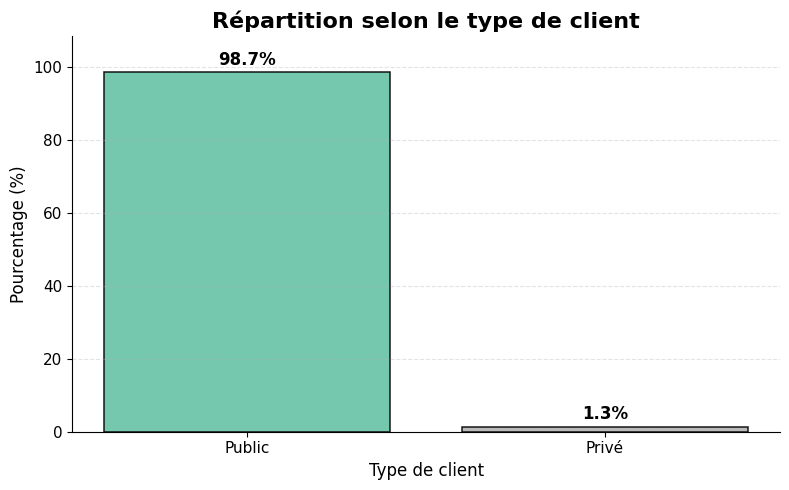

In [52]:
# Calcul des pourcentages
data = (
    df['TYPE_CLIENT']
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
)

# Couleurs professionnelles
colors = plt.cm.Set2(np.linspace(0, 1, len(data)))

# Création du graphique
plt.figure(figsize=(8, 5))

bars = plt.bar(
    data.index,
    data.values,
    color=colors,
    edgecolor='black',
    linewidth=1.1,
    alpha=0.90
)

ax = plt.gca()

# Ajouter les pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

# Personnalisation
plt.title("Répartition selon le type de client", fontsize=16, fontweight='bold')
plt.xlabel("Type de client", fontsize=12)
plt.ylabel("Pourcentage (%)", fontsize=12)

plt.ylim(0, data.max() + 10)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)

# Supprimer les lignes verticales et garder seulement les lignes horizontales
ax.grid(False)
ax.grid(axis='y', linestyle='--', alpha=0.35)

# Supprimer les bordures inutiles
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### DEFAUT (target variable)

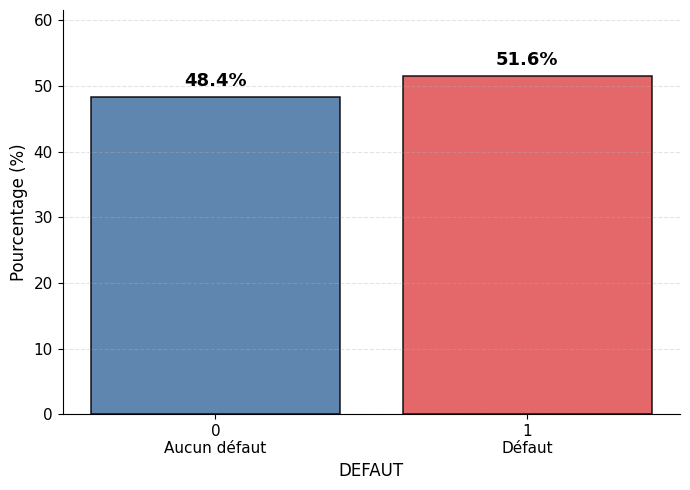

In [66]:
# Calcul des pourcentages
data = (
    df['DEFAUT']
    .value_counts(normalize=True)
    .mul(100)
    .sort_index()
)

# Création du graphique
plt.figure(figsize=(7, 5))

colors = ['#4E79A7', '#E15759']

bars = plt.bar(
    data.index.astype(str),   # garder 0 et 1 dans le graphique
    data.values,
    color=colors,
    edgecolor='black',
    linewidth=1.1,
    alpha=0.90
)

ax = plt.gca()

# Ajouter les pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold'
    )

# Personnalisation
# plt.title("Répartition de la variable cible DEFAUT", fontsize=16, fontweight='bold')
plt.xlabel("DEFAUT", fontsize=12)
plt.ylabel("Pourcentage (%)", fontsize=12)

plt.xticks(
    ticks=[0, 1],
    labels=[
        "0\nAucun défaut",
        "1\nDéfaut"
    ],
    fontsize=11
)

plt.yticks(fontsize=11)
plt.ylim(0, data.max() + 10)

# Grille propre
ax.grid(False)
ax.grid(axis='y', linestyle='--', alpha=0.35)

# Supprimer les bordures inutiles
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Ce graphique présente la distribution de la variable cible **DEFAUT**. On observe que les deux classes sont presque équilibrées : les dossiers sans défaut représentent **48,4 %**, tandis que les dossiers en défaut représentent **51,6 %**. Cette répartition est importante pour la suite de l’analyse, car elle montre qu’aucune classe ne domine fortement l’autre. Ainsi, le modèle de classification pourra apprendre à distinguer les deux situations dans de meilleures conditions, sans être trop influencé par une classe majoritaire.
